# Chasing the Headline - How Retail Investors Are Driven by Hype and Panic

<img src="img/NYSE.jpg" style="width:100%; object-fit:cover; object-position:center; display:block;">

<div style="border-left: 4px solid #ccc; padding: 10px 20px; margin: 20px 0; font-style: italic; color: #555; white-space: normal !important; word-wrap: break-word; font-family: Georgia, serif;">
In general, retail investors don't follow fundamental, technical or quantitative analysis in their investment decisions. It is driven mostly by hype or panic and Google Trends shows this relationship.
</div>

## Introduction

Every couple of months, there will be some major news about a certain stock, technology or event that draws the attention of everyday people back to the stock market. AI explodes, Nvidia stock shoots up, suddenly people from all different backgrounds want to enter the market and now everyone is googling a ticker that they'd never heard of six months ago. 

But is this crowd attention a signal or a symptom? Are the people early or are they always late?

Using Google Trends search data alongside GameStop's actual stock price, we can map out exactly how public attention moves relative to markets. The story that emerges is both predictable and painful. **The crowd almost always shows up late**.

To investigate, we track five search terms across 20 years:

| Search Term | What it represents |
|---|---|
| `"stock market"` | General public awareness |
| `"stock market crash"` | Fear and panic |
| `"GME"` | Gamestop ticker, related to a meme driven surge in price a couple years ago |
| `"Bitcoin"` | Crypto hype cycles |
| `"NVDA"` | AI driven sustained growth |

<hr style="border:none; border-top:2px solid #e0e0e0; margin:40px 0;">

### Loading the Data

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Load Google Trends ---
bitcoin_df = pd.read_csv('data/bitcoin.csv')
gme_df = pd.read_csv('data/gme.csv')
market_crash_df = pd.read_csv('data/market_crash.csv')
nvda_df = pd.read_csv('data/nvda.csv')
stock_market_df = pd.read_csv('data/stock_market.csv')

# Standardise Trends dataframes
dfs = {
    'Bitcoin': bitcoin_df,
    'GME': gme_df,
    'Market Crash': market_crash_df,
    'NVDA': nvda_df,
    'Stock Market': stock_market_df
}

for name, df in dfs.items():
    df.columns = ['Date', 'Interest']
    df['Date'] = pd.to_datetime(df['Date'])
    df['Interest'] = pd.to_numeric(df['Interest'], errors='coerce')
    df.set_index('Date', inplace=True)

combined = pd.DataFrame({name: df['Interest'] for name, df in dfs.items()})

# --- Load GME Price ---
gme_price_df = pd.read_csv('data/GME_price.csv')
gme_price_df['Date'] = pd.to_datetime(gme_price_df['Date'])
gme_price_df.set_index('Date', inplace=True)
gme_price_df.sort_index(inplace=True)
gme_price_df.columns = gme_price_df.columns.str.replace('\xa0', '', regex=False).str.strip()

<hr style="border:none; border-top:2px solid #e0e0e0; margin:40px 0;">

## Part 1: The Big Picture - 20 Years of Market Attention

First, let's look at the big picture in terms of trends. The chart below plots all five search terms from 2004 to present. 

Immediately, we can see a couple of familiar spikes including the 2008 financial crisis, the COVID crash, the crypto boom and most recently, the AI frenzy. Each spike tells a story about what the public was paying attention to and when. 

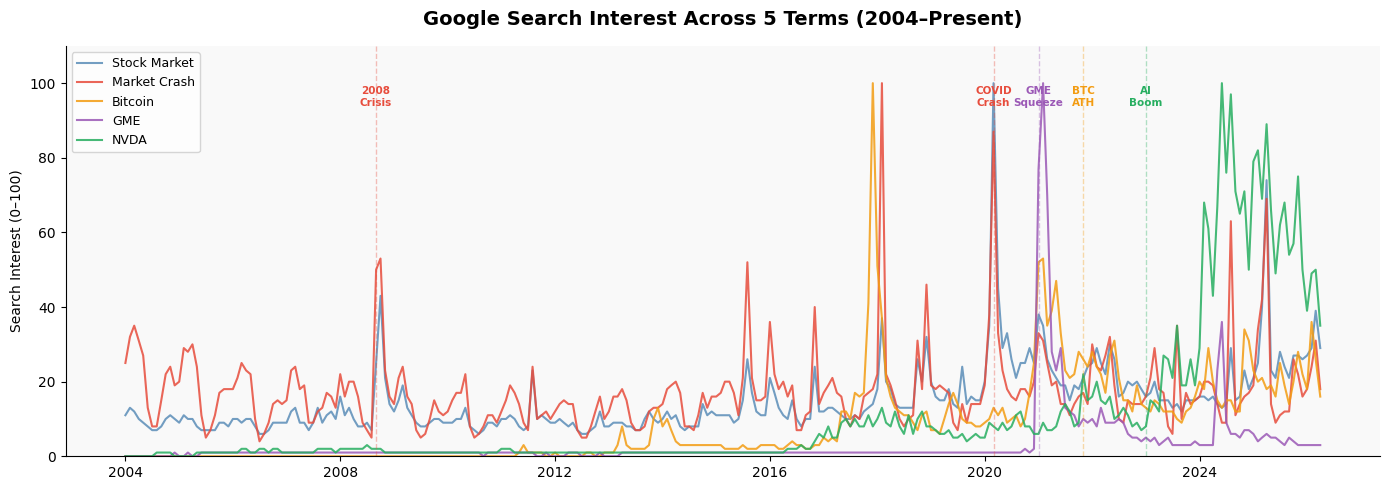

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = {
    'Stock Market': '#5b8db8',
    'Market Crash': '#e74c3c',
    'Bitcoin': '#f39c12',
    'GME': '#9b59b6',
    'NVDA': '#27ae60'
}

for name, color in colors.items():
    ax.plot(combined.index, combined[name], 
            label=name, color=color, linewidth=1.5, alpha=0.85)

events = {
    '2008-09-01': ('2008\nCrisis', '#e74c3c'),
    '2020-03-01': ('COVID\nCrash', '#e74c3c'),
    '2021-01-01': ('GME\nSqueeze', '#9b59b6'),
    '2021-11-01': ('BTC\nATH', '#f39c12'),
    '2023-01-01': ('AI\nBoom', '#27ae60'),
}

for date, (label, color) in events.items():
    ax.axvline(pd.to_datetime(date), color=color, linestyle='--', alpha=0.35, linewidth=1)
    ax.text(pd.to_datetime(date), 94, label, color=color, 
            fontsize=7.5, ha='center', fontweight='bold')

ax.set_title('Google Search Interest Across 5 Terms (2004–Present)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Search Interest (0–100)')
ax.legend(loc='upper left', fontsize=9)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('img/overview.png', dpi=150, bbox_inches='tight')
plt.show()

<hr style="border:none; border-top:2px solid #e0e0e0; margin:40px 0;">

## Part 2: Fear is Always Late

The red line in the chart above depicts the number of searches made for *"stock market crash."*

You might expect people to search for this **before** a crash as a warning signal where individuals try to ready their portfolios to withstand a market downturn. The data however, tells the opposite story. The spikes in fear driven searches coincide with or **follows** the moment markets have already collapsed.

In 2008, search interest in "stock market crash" peaked in **October**, a month after Lehman Brothers filed for bankruptcy and the market had already plummeted. In March 2020, with the hit of COVID-19, the spike in searches came as the markets were already in freefall. 

This data shows that retail, everyday, investors who make up the majority of google searches don't anticipate disaster. They react to it.

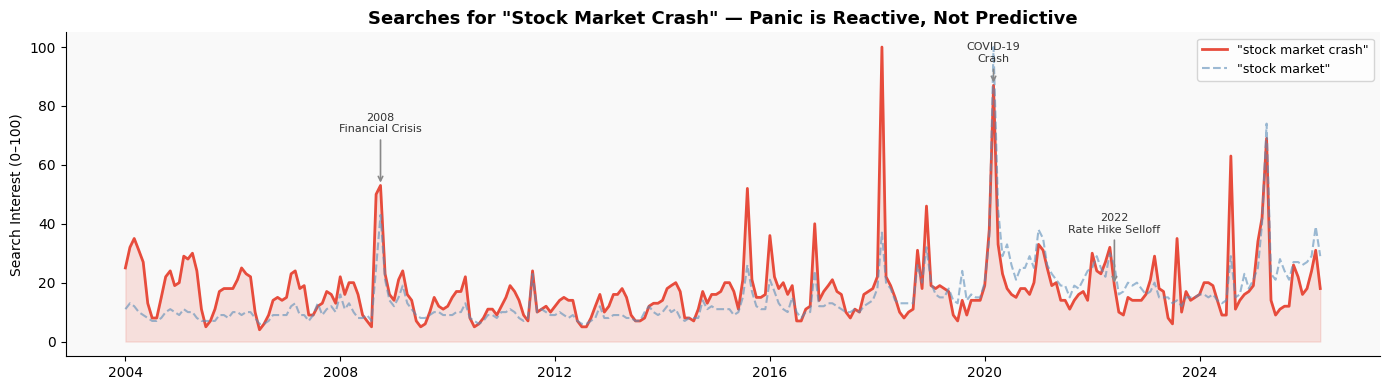

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(combined.index, combined['Market Crash'], 
                alpha=0.15, color='#e74c3c')
ax.plot(combined.index, combined['Market Crash'], 
        color='#e74c3c', linewidth=2, label='"stock market crash"')
ax.plot(combined.index, combined['Stock Market'], 
        color='#5b8db8', linewidth=1.5, linestyle='--', 
        alpha=0.6, label='"stock market"')

crisis_annotations = [
    ('2008-10-01', '2008\nFinancial Crisis'),
    ('2020-03-01', 'COVID-19\nCrash'),
    ('2022-06-01', '2022\nRate Hike Selloff'),
]

for date, label in crisis_annotations:
    x = pd.to_datetime(date)
    if x in combined.index:
        y = combined.loc[x, 'Market Crash']
    else:
        y = 40
    ax.annotate(label, xy=(x, y), 
                xytext=(x, min(y + 18, 95)),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.2),
                fontsize=8, ha='center', color='#333')

ax.set_title('Searches for "Stock Market Crash" — Panic is Reactive, Not Predictive', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Search Interest (0–100)')
ax.legend(fontsize=9)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('img/fear_chart.png', dpi=150, bbox_inches='tight')
plt.show()

<hr style="border:none; border-top:2px solid #e0e0e0; margin:40px 0;">

## Part 3: Greed Falls Even Further Behind

If fear arrives late, greed arrives even later with searches beginning right at the peak of the growth.

One of the clearest examples of this is with GameStop (GME). In January 2021, a coordinated effort on Reddit's r/WallStreetBets drove GME's stock price from around **$20** to nearly **$500** in a matter of weeks. This was a collaborative effort by internet trolls who wanted to beat the forecasts and calculations of Wall Street's biggest firms, collectively pushing to an undeserved high.

As expected, it becoame the most talked about stock on the planet.

The chart below overlays Google search interest in "GME" against the actual closing price. The pattern is striking but expected, with search interest exploding as the price peaks and then both collapse together. The people googling "how to buy GME" in late January of 2021 were buying the peak of one of the most violent short squeezes in history.

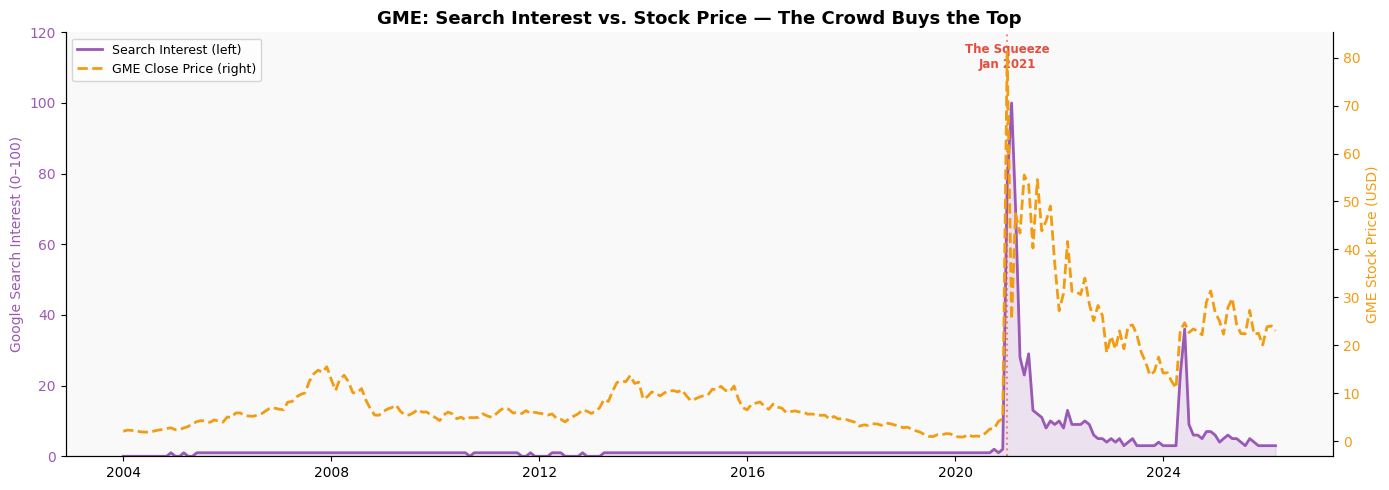

In [20]:
# Align on overlapping dates
gme_overlap = combined['GME'].dropna()
price_overlap = gme_price_df['Close'].dropna()
shared_dates = gme_overlap.index.intersection(price_overlap.index)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Search interest
ax1.fill_between(shared_dates, gme_overlap[shared_dates], 
                 alpha=0.15, color='#9b59b6')
ax1.plot(shared_dates, gme_overlap[shared_dates], 
         color='#9b59b6', linewidth=2, label='Search Interest (left)')
ax1.set_ylabel('Google Search Interest (0–100)', color='#9b59b6')
ax1.tick_params(axis='y', labelcolor='#9b59b6')
ax1.set_ylim(0, 120)

# Price
ax2 = ax1.twinx()
ax2.plot(shared_dates, price_overlap[shared_dates], 
         color='#f39c12', linewidth=2, linestyle='--', label='GME Close Price (right)')
ax2.set_ylabel('GME Stock Price (USD)', color='#f39c12')
ax2.tick_params(axis='y', labelcolor='#f39c12')

# Annotate the squeeze
squeeze_date = pd.to_datetime('2021-01-01')
ax1.axvline(squeeze_date, color='#e74c3c', linestyle=':', alpha=0.6)
ax1.text(squeeze_date, 110, 'The Squeeze\nJan 2021', 
         color='#e74c3c', fontsize=8.5, ha='center', fontweight='bold')

ax1.set_title('GME: Search Interest vs. Stock Price — The Crowd Buys the Top', 
              fontsize=13, fontweight='bold')
ax1.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('img/gme_dual.png', dpi=150, bbox_inches='tight')
plt.show()

<hr style="border:none; border-top:2px solid #e0e0e0; margin:40px 0;">

## Part 4: Bitcoin - The Hype Cycle on Repeat

GameStop was a one time event. An outlier in which the stock should have never moved like that. Bitcoin on the other hand is a recurring one. 

Since 2017, Bitcoin has gone through at least three distinct hype cycles, following the same pattern every time. First a slow build followed by an exponential spike in both price and search interest and finally, a collapse back to support levels, as retail investors are left behind, always too late to respond. 

What makes Bitcoin uniquely interesting is that the cycle has repeated multiple times. Each peak brings in a new wave of investors wwho missed the last one, convinced that they can profit this time.

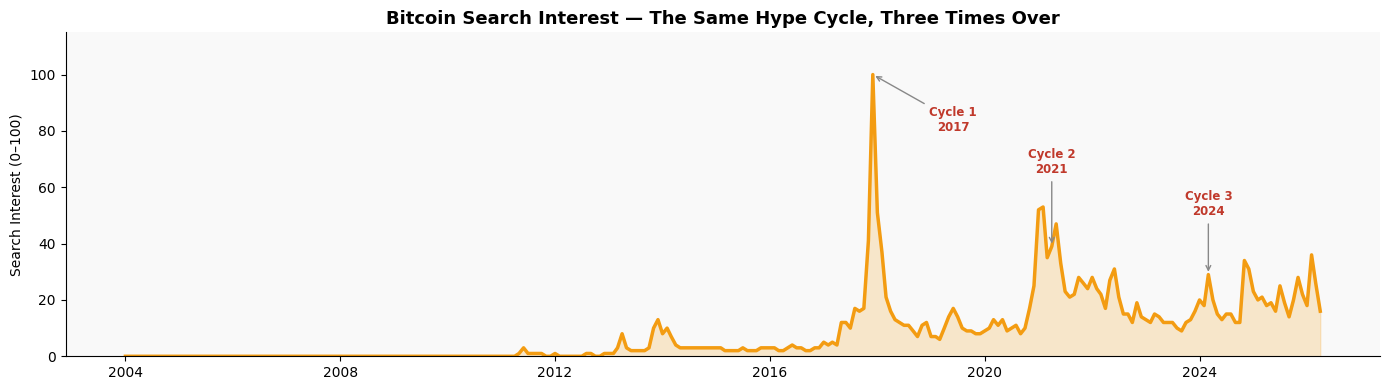

In [23]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(combined.index, combined['Bitcoin'], 
                alpha=0.2, color='#f39c12')
ax.plot(combined.index, combined['Bitcoin'], 
        color='#f39c12', linewidth=2.5, label='Bitcoin')

cycles = {
    '2017-12-01': ('Cycle 1\n2017', '2019-06-01', 80),   # (label, text_x, text_y)
    '2021-04-01': ('Cycle 2\n2021', '2021-04-01', 65),
    '2024-03-01': ('Cycle 3\n2024', '2024-03-01', 50),
}

for date, (label, text_date, text_y) in cycles.items():
    x = pd.to_datetime(date)
    tx = pd.to_datetime(text_date)
    if x in combined.index:
        y = combined.loc[x, 'Bitcoin']
        ax.annotate(label, xy=(x, y),
                    xytext=(tx, text_y),
                    arrowprops=dict(arrowstyle='->', color='#888'),
                    fontsize=8.5, ha='center', color='#c0392b', fontweight='bold')

ax.set_title('Bitcoin Search Interest — The Same Hype Cycle, Three Times Over', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Search Interest (0–100)')
ax.set_ylim(0, 115)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('img/bitcoin_chart.png', dpi=150, bbox_inches='tight')
plt.show()

<hr style="border:none; border-top:2px solid #e0e0e0; margin:40px 0;">

## Part 5: Is NVIDIA Good to Retail Investors

Now consider NVIDIA (NVDA) where the stock didn't just shoot up overnight. It grew steadily from the late 2022 onwards, driven by a fundamental transformation in the company's business, primarily driven by AI chip demand. By 2024, NVIDIA had become one of the most valuable companies in the world. 

So then, in this case, did the public get it right?

The answer is still no. While the search trend does reflect the company's real fundamental growth with the company's revenue and earnings repeatedly smashing expectations, you can find that the public is always too late. Zoom in and you will find that the biggest spike in search interest came after the stock had multiplied already several times over. The crowd noticed, but just as always, after the main action. 

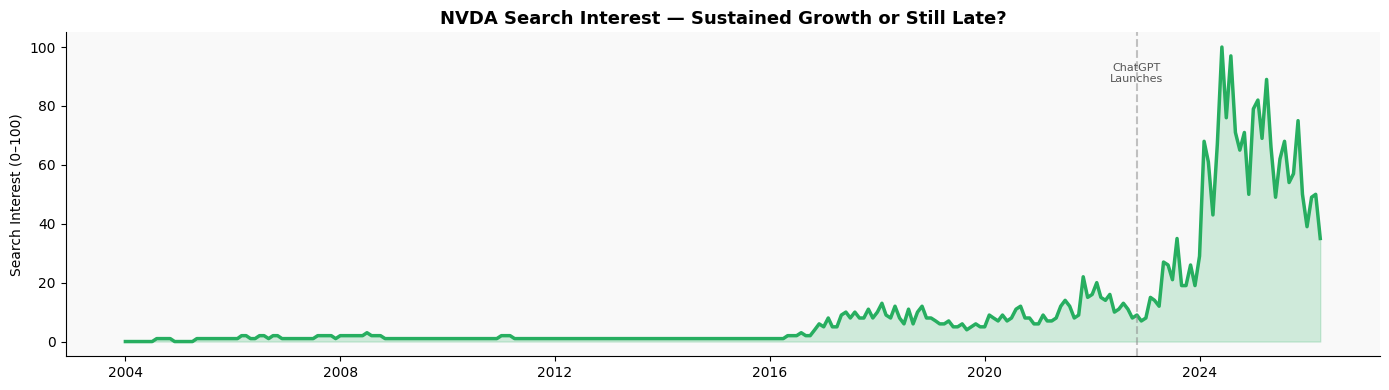

In [24]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(combined.index, combined['NVDA'], 
                alpha=0.2, color='#27ae60')
ax.plot(combined.index, combined['NVDA'], 
        color='#27ae60', linewidth=2.5)

ax.axvline(pd.to_datetime('2022-11-01'), color='#888', linestyle='--', alpha=0.5)
ax.text(pd.to_datetime('2022-11-01'), 88, 'ChatGPT\nLaunches', 
        color='#555', fontsize=8, ha='center')

ax.set_title('NVDA Search Interest — Sustained Growth or Still Late?', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Search Interest (0–100)')
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('img/nvda_chart.png', dpi=150, bbox_inches='tight')
plt.show()

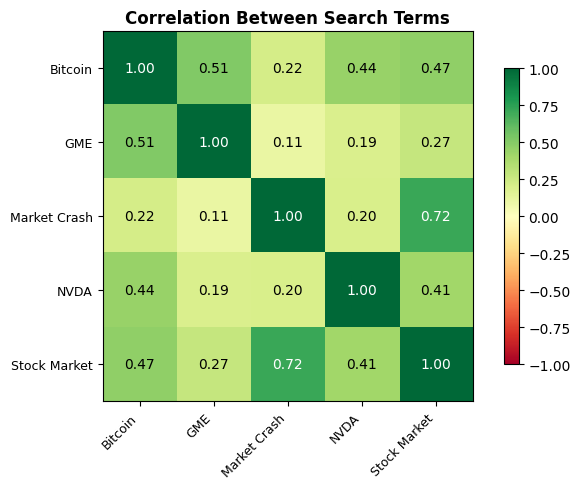

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))

corr = combined.corr()
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', 
                ha='center', va='center', fontsize=10,
                color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')

ax.set_title('Correlation Between Search Terms', fontweight='bold', fontsize=12)
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.savefig('img/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

<hr style="border:none; border-top:2px solid #e0e0e0; margin:40px 0;">

## Conclusion: The Crowd is a Follower

By analysing twenty years of Google search data across multiple assests, we can observe a consistent pattern in retail investor behaviour.

**When things go wrong**, the public panics, but only after the damage is done. The public reacts too late to save themselves.

**When things go right**, the crowd piles in at the peak. They join in too late and are unable to take any profit.

Google Trends shows that searches from the public can't predict markets. While search interest is genuinely tied to significant market events, it's always too late, perfectly depicting human psychology. The crowd chases headlines, arrives too late and repeats the cycle with every new asset class.